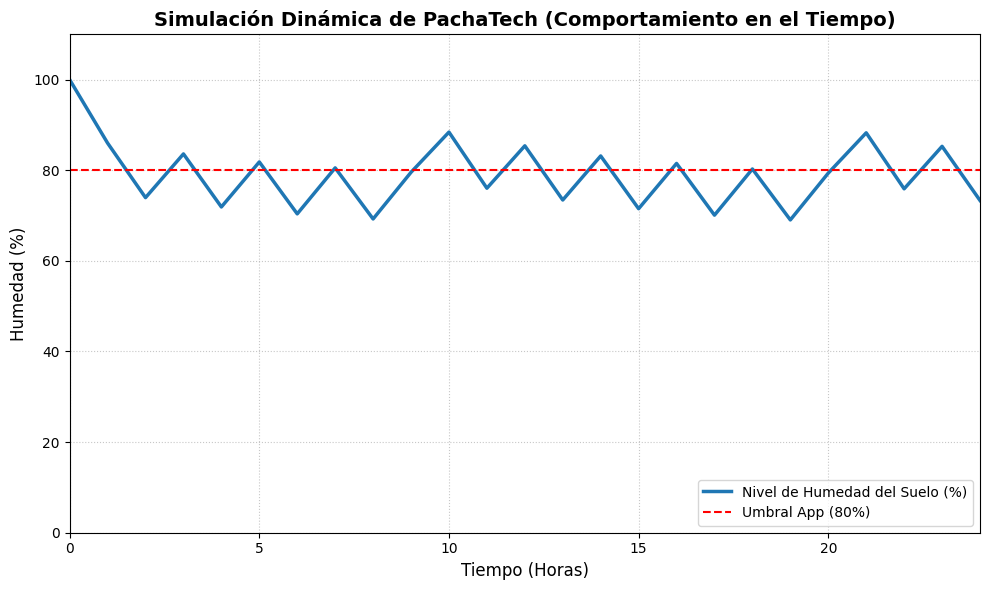

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración del Tiempo
dt = 1  # Paso de simulación (1 hora)
tiempo = np.arange(0, 25, dt)  # Horizonte de 24 horas

# 2. Inicialización de Variables de Estado (Stock)
nivel_humedad_suelo = np.zeros(len(tiempo))
nivel_humedad_suelo[0] = 100  # Condición inicial: Tierra saturada al 100%

# 3. Parámetros y Variables Exógenas (Escenario Base - Ola de calor)
temp_dht11 = 28
umbral_app = 80
modo_operacion = 2
constante_evaporacion = 0.5

# 4. Bucle de Simulación Dinámica (Método de Euler)
for i in range(1, len(tiempo)):

    # Calcular Tasa de Salida (Evapotranspiración)
    tasa_secado = constante_evaporacion * temp_dht11 * (nivel_humedad_suelo[i-1] / 100)

    # Calcular Flujo de Entrada (Lógica IF THEN ELSE del Arduino)
    if modo_operacion == 2 and nivel_humedad_suelo[i-1] < umbral_app:
        flujo_riego = 20
    else:
        flujo_riego = 0

    # Ecuación de Nivel (Stock = Stock_anterior + (Entradas - Salidas) * dt)
    nivel_humedad_suelo[i] = nivel_humedad_suelo[i-1] + (flujo_riego - tasa_secado) * dt

# 5. Generación del Gráfico (Behavior Over Time - BOT)
plt.figure(figsize=(10, 6))
plt.plot(tiempo, nivel_humedad_suelo, label='Nivel de Humedad del Suelo (%)', color='#1f77b4', linewidth=2.5)
plt.axhline(y=umbral_app, color='red', linestyle='--', label='Umbral App (80%)')

# Detalles estéticos del gráfico
plt.title('Simulación Dinámica de PachaTech (Comportamiento en el Tiempo)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Horas)', fontsize=12)
plt.ylabel('Humedad (%)', fontsize=12)
plt.ylim(0, 110)
plt.xlim(0, 24)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Mostrar gráfico
plt.show()